#  Сегментация изображений

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* https://www.kaggle.com/datasets/rajkumarl/people-clothing-segmentation/data
* https://pyimagesearch.com/2021/11/08/u-net-training-image-segmentation-models-in-pytorch/
* https://amaarora.github.io/posts/2020-09-13-unet.html
* https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html
* https://medium.com/apache-mxnet/transposed-convolutions-explained-with-ms-excel-52d13030c7e8
* https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md
* https://huggingface.co/docs/transformers/model_doc/segformer
* https://www.kaggle.com/code/damianpanek/segformerb0-people-clothing-segmentation

## Задачи для совместного разбора

1\. Обсудите постановку задачи сегментации изображений.

2\. Рассмотрите пример работы слоя `ConvTranspose2d`.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Опишите датасет `ClothesSegmentationDataset`. Реализуйте `__getitem__` таким образом, чтобы он возвращал два элемента: тензор с изображением и тензор с маской. Маска должна быть представлена трехмерным тензором целых чисел. Предусмотрите возможность передавать извне при создании датасета набор преобразований для изображений и масок. Создайте объект датасета и выведите на экран форму и типы одного изображения и его маски.

- [ ] Проверено на семинаре

In [ ]:
import os
from typing import List, Callable, Optional

import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import glob
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from collections import Counter
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
!unzip archive.zip -d /content/data

In [ ]:
image_paths = ["/content/data/Train/Image/10249.jpg"]
mask_paths = ["/content/data/Train/Mask/10249.jpg.png"]


In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

def mask_transform_fn(mask):
    mask = mask.resize((256, 256), resample=Image.NEAREST)
    mask = np.array(mask, dtype=np.int64)
    mask = torch.from_numpy(mask)
    if mask.ndim == 2:
        mask = mask.unsqueeze(0)
    return mask


In [ ]:
dataset = ClothesSegmentationDataset(
    image_paths=image_paths,
    mask_paths=mask_paths,
    image_transform=image_transform,
    mask_transform=mask_transform_fn
)

In [ ]:
img, msk = dataset[0]
print("Тип изображения:", type(img))
print("Форма изображения:", img.shape)
print("Тип маски:", type(msk))
print("Форма маски:", msk.shape)
print("Dtype маски:", msk.dtype)

Тип изображения: <class 'torch.Tensor'>
Форма изображения: torch.Size([3, 256, 256])
Тип маски: <class 'torch.Tensor'>
Форма маски: torch.Size([1, 256, 256])
Dtype маски: torch.int64


<p class="task" id="2"></p>

2\. Напишите функцию `show_image_with_mask`, которая выводит рядом два изображения: фотографию и маску. Продемонстрируйте работу функции, взяв один пример из созданного датасета.

- [ ] Проверено на семинаре

In [ ]:
def show_image_with_mask(image_tensor, mask_tensor):
    if isinstance(image_tensor, torch.Tensor):
        img_np = image_tensor.detach().cpu().numpy()
     # [C, H, W] -> [H, W, C]
        if img_np.ndim == 3 and (img_np.shape[0] == 3 or img_np.shape[0] == 1):
            img_np = np.transpose(img_np, (1, 2, 0))
        img_np = np.clip(img_np, 0, 1)
    else:
        img_np = image_tensor

    if isinstance(mask_tensor, torch.Tensor):
        mask_np = mask_tensor.detach().cpu().numpy()
        # [1, H, W] -> [H, W]
        if mask_np.ndim == 3 and mask_np.shape[0] == 1:
            mask_np = mask_np[0]
        # если  [H, W, 1]
        elif mask_np.ndim == 3 and mask_np.shape[-1] == 1:
            mask_np = mask_np[:, :, 0]
    else:
        mask_np = mask_tensor

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    axs[0].imshow(img_np)
    axs[0].set_title('Image')
    axs[0].axis('off')

    axs[1].imshow(mask_np, cmap='gray')
    axs[1].set_title('Mask')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()


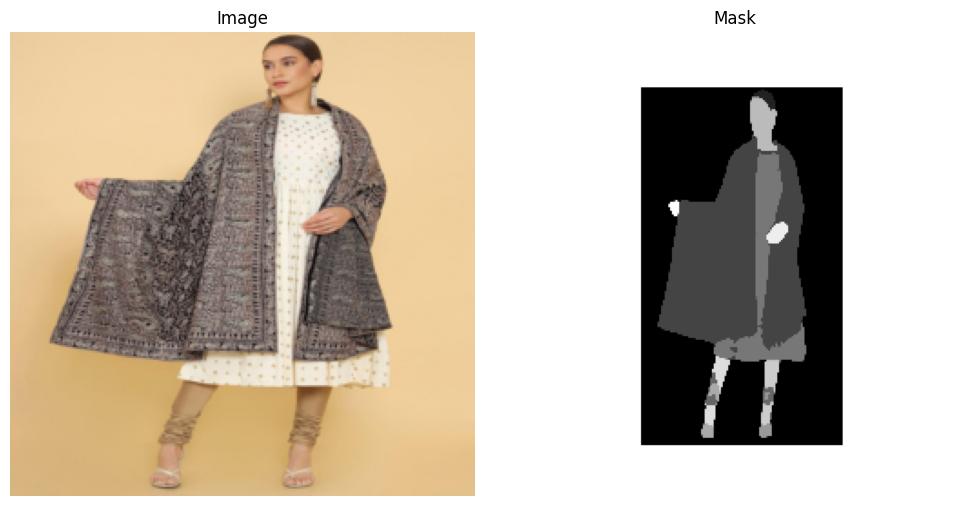

In [ ]:
img, msk = dataset[0]
show_image_with_mask(img, msk)


<p class="task" id="3"></p>

3\. Реализуйте архитектуру U-Net. Реализуйте модель таким образом, чтобы на выходе для каждого изображения получался тензор размера `n_classes x h x w`, где `n_classes` - количество уникальных значений в масках, а `h` и `w` - размер исходного изображения. Возьмите один пример из набора данных и пропустите его через сеть. Выведите форму полученного результата на экран.

- [ ] Проверено на семинаре

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.model(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels, n_classes):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.out_conv(d1)
        # [batch, n_classes, H, W]
        return out

In [ ]:
img, msk = dataset[0]
img = img.unsqueeze(0)             # + batch dim: [1, 3, H, W]
n_classes = len(torch.unique(msk))
print("n_classes:", n_classes)

model = UNet(in_channels=3, n_classes=n_classes)

output = model(img)                # [1, n_classes, H, W]
print("Output shape:", output.shape)

n_classes: 129
Output shape: torch.Size([1, 129, 256, 256])


<p class="task" id="4"></p>

4\.  Разбейте набор данных на обучающее и валидационное множество. Обучите модель U-Net для сегментации изображения. Во время обучения выводите на экран значения функции потерь и точности прогнозов на обучающем и валидационном множестве. Обратите внимание, что выборка является несбалансированной. При расчете функции потерь примените любую известную вам технику для работы с несбалансированными выборками.

При создании датасета допускается использовать преобразования, уменьшающие размер изображений (для ускорения процесса обучения).

Используя обученную модель, получите предсказания для нескольких изображений и отрисуйте их.
- [ ] Проверено на семинаре

In [ ]:
img_dir = "/content/data/Train/Image"
mask_dir = "/content/data/Train/Mask"
image_paths = sorted(glob.glob(img_dir + "/*.jpg"))
mask_paths = [mask_dir + "/" + os.path.basename(p) + ".png" for p in image_paths]

train_img, val_img, train_mask, val_mask = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42)


In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

def mask_transform_fn(mask):
    mask = mask.resize((128, 128), resample=Image.NEAREST)
    mask = np.array(mask, dtype=np.int64)
    mask = torch.from_numpy(mask)
    if mask.ndim == 2:
        mask = mask.unsqueeze(0)
    return mask

train_dataset = ClothesSegmentationDataset(train_img, train_mask, image_transform, mask_transform_fn)
val_dataset   = ClothesSegmentationDataset(val_img,   val_mask,   image_transform, mask_transform_fn)


In [ ]:
all_classes = set()
for _, mask in train_dataset:
    all_classes.update(np.unique(mask.numpy()))
all_classes = sorted(list(all_classes))
class_to_index = {cls: i for i, cls in enumerate(all_classes)}
index_to_class = {i: cls for i, cls in enumerate(all_classes)}
n_classes = len(all_classes)

def remap_mask(mask, device=None):
    mask_np = mask.cpu().numpy()
    for old, new in class_to_index.items():
        mask_np[mask_np == old] = new
    tensor = torch.from_numpy(mask_np).long()
    if device is not None:
        tensor = tensor.to(device)
    else:
        tensor = tensor.to(mask.device)
    return tensor


In [ ]:
all_mask_pixels = []
for _, mask in train_dataset:
    mask_remapped = remap_mask(mask, device='cpu')
    all_mask_pixels.extend(mask_remapped.view(-1).tolist())
counts = Counter(all_mask_pixels)
total = sum(counts.values())
weights = [1.0 / (counts[i] / total + 1e-6) for i in range(n_classes)]
weights = torch.tensor(weights, dtype=torch.float).to('cuda')


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(in_channels=3, n_classes=n_classes).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
def compute_accuracy(pred, target):
    pred_classes = pred.argmax(dim=1)
    gt = target.squeeze(1)
    correct = (pred_classes == gt).float()
    return correct.mean().item()


In [ ]:
num_epochs = 10
best_val_loss = float('inf')
for epoch in range(num_epochs):
    model.train()
    train_loss, train_acc = 0, 0
    for images, masks in tqdm(train_loader, desc=f"Train epoch {epoch+1}"):
        images = images.to(device)
        masks = masks.to(device)
        masks = torch.stack([remap_mask(m, device=device) for m in masks])
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks.squeeze(1))
        acc = compute_accuracy(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc += acc
    train_loss /= len(train_loader)
    train_acc  /= len(train_loader)

    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Val epoch {epoch+1}"):
            images = images.to(device)
            masks = masks.to(device)
            masks = torch.stack([remap_mask(m, device=device) for m in masks])
            outputs = model(images)
            loss = loss_fn(outputs, masks.squeeze(1))
            acc = compute_accuracy(outputs, masks)
            val_loss += loss.item()
            val_acc += acc
    val_loss /= len(val_loader)
    val_acc  /= len(val_loader)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | "
          f"Val Loss={val_loss:.4f}, Acc={val_acc:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_unet.pth")
        print("Лучшие веса сохранены!")


Val epoch 1: 100%|██████████| 5/5 [00:02<00:00,  2.24it/s]


Epoch 1: Train Loss=5.5337, Acc=0.0261 | Val Loss=5.4797, Acc=0.0285
Лучшие веса сохранены!


Val epoch 2: 100%|██████████| 5/5 [00:02<00:00,  2.21it/s]


Epoch 2: Train Loss=5.4229, Acc=0.0302 | Val Loss=5.5191, Acc=0.0626


Val epoch 3: 100%|██████████| 5/5 [00:02<00:00,  2.25it/s]


...

Epoch 8: Train Loss=4.5547, Acc=0.0161 | Val Loss=5.6322, Acc=0.0143


Val epoch 9: 100%|██████████| 5/5 [00:02<00:00,  2.27it/s]


Epoch 9: Train Loss=4.3343, Acc=0.0143 | Val Loss=5.7548, Acc=0.0086


Val epoch 10: 100%|██████████| 5/5 [00:02<00:00,  2.20it/s]

Epoch 10: Train Loss=3.9988, Acc=0.0069 | Val Loss=6.1401, Acc=0.0020


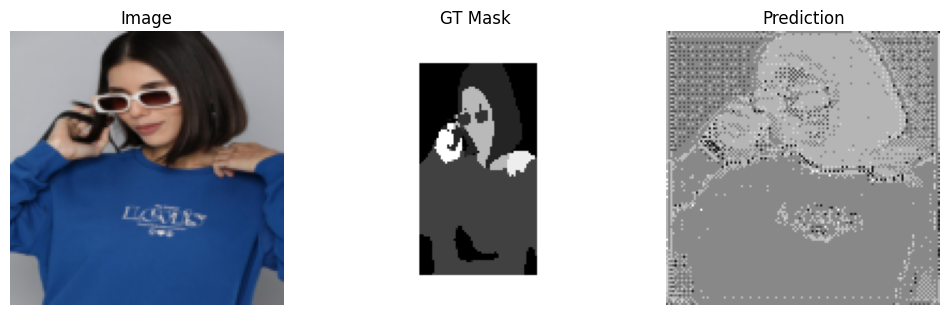

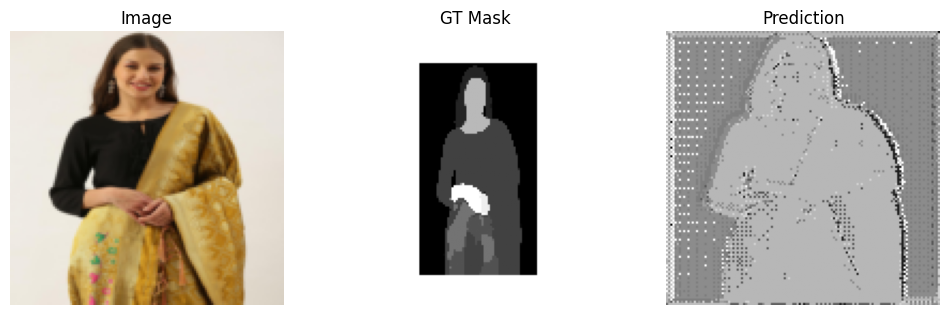

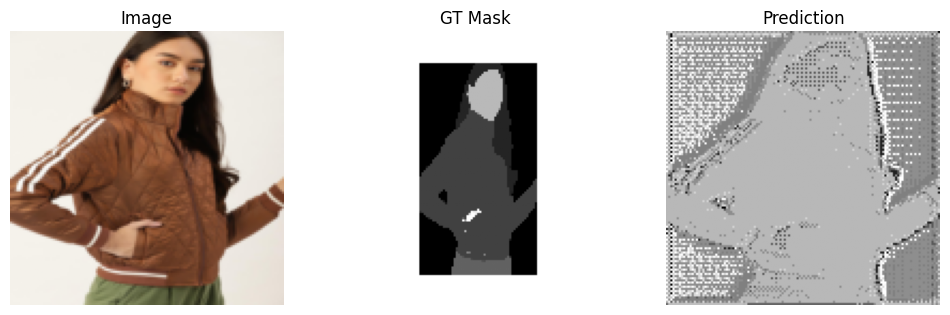

In [ ]:
for i in range(3):
    img, mask = val_dataset[i]
    img_cpu = img.permute(1,2,0).cpu().numpy()
    mask_remapped = remap_mask(mask, device='cpu')
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(dim=1).cpu().squeeze().numpy()
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img_cpu)
    axs[0].set_title("Image")
    axs[1].imshow(mask_remapped.cpu().numpy().squeeze(), cmap="gray")
    axs[1].set_title("GT Mask")
    axs[2].imshow(pred, cmap="gray")
    axs[2].set_title("Prediction")
    for ax in axs: ax.axis('off')
    plt.show()


<p class="task" id="5"></p>

5\.  Обучите модуль `SegformerForSemanticSegmentation` из пакета `transformers` для сегментации изображения. Во время обучения выводите на экран значения функции потерь и точности прогнозов на обучающем и валидационном множестве. Для оптимизации используйте значение функции потерь, которое возвращает вам модель.

Используя обученную модель, получите предсказания для нескольких изображений и отрисуйте их.
- [ ] Проверено на семинаре

In [ ]:
from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation

In [ ]:
img_dir = "/content/data/Train/Image"
mask_dir = "/content/data/Train/Mask"
image_paths = sorted(glob.glob(img_dir + "/*.jpg"))
mask_paths  = [mask_dir + "/" + os.path.basename(p) + ".png" for p in image_paths]

train_img, val_img, train_mask, val_mask = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

from collections import Counter
all_classes = []
class_counts = Counter()
for mp in train_mask:
    arr = np.array(Image.open(mp).convert("L"))
    u, c = np.unique(arr, return_counts=True)
    all_classes.extend(u)
    class_counts.update(dict(zip(u, c)))
all_classes = sorted(set(all_classes))
class_to_index = {cls: i for i, cls in enumerate(all_classes)}
num_classes = len(all_classes)


In [ ]:
total_pixels = sum(class_counts.values())
weights = []
for i in range(num_classes):
    freq = class_counts.get(all_classes[i], 0) / total_pixels
    weights.append(1.0 / freq if freq > 0 else 0.0)

weights = np.clip(weights, 1, 20)
weights_tensor = torch.tensor(weights, dtype=torch.float)


In [ ]:
processor = SegformerFeatureExtractor.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
processor.size = 128

class SegformerCustomDataset(Dataset):
    def __init__(self, img_paths, mask_paths, processor, class_to_index):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.processor = processor
        self.class_to_index = class_to_index
    def __len__(self): return len(self.img_paths)
    def __getitem__(self, idx):
        image = Image.open(self.img_paths[idx]).convert('RGB')
        mask = Image.open(self.mask_paths[idx]).convert('L').resize((self.processor.size, self.processor.size), resample=Image.NEAREST)
        mask_np = np.array(mask)
        mask_remap = np.zeros_like(mask_np)
        for cls, idx_ in self.class_to_index.items():
            mask_remap[mask_np==cls] = idx_
        enc = self.processor(image, return_tensors='pt')
        enc["labels"] = torch.from_numpy(mask_remap).long()
        for k in enc:
            if isinstance(enc[k], torch.Tensor) and enc[k].ndim > 0 and enc[k].shape[0]==1:
                enc[k] = enc[k].squeeze(0)
        return enc

train_dataset = SegformerCustomDataset(train_img, train_mask, processor, class_to_index)
val_dataset   = SegformerCustomDataset(val_img, val_mask, processor, class_to_index)
BATCH = 4
train_loader = DataLoader(train_dataset, batch_size=BATCH)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels = num_classes,
    id2label = {str(i):str(i) for i in range(num_classes)},
    label2id = {str(i):i for i in range(num_classes)},
    ignore_mismatched_sizes = True,
)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

model.config.class_weight = weights_tensor.to(device)


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([232]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([232, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def compute_miou(pred_mask, true_mask, num_classes):
    pred_mask = pred_mask.cpu().numpy()
    true_mask = true_mask.cpu().numpy()
    ious = []
    for cls in range(num_classes):
        pred_cls = (pred_mask == cls)
        true_cls = (true_mask == cls)
        if true_cls.sum() == 0 and pred_cls.sum() == 0:
            continue
        intersection = np.logical_and(pred_cls, true_cls).sum()
        union = np.logical_or(pred_cls, true_cls).sum()
        if union == 0:
            continue
        ious.append(intersection / union)
    return np.nanmean(ious) if len(ious) > 0 else float('nan')


In [ ]:
EPOCHS = 10
for epoch in range(EPOCHS):
    model.train(); tr_loss=tr_acc=tr_miou=tr_batches=0
    for batch in tqdm(train_loader, desc=f"Train {epoch+1}"):
        optimizer.zero_grad()
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)
        out = model(pixel_values=pixel_values, labels=labels)
        loss = out.loss
        logits = out.logits
        logits = F.interpolate(logits, size=labels.shape[-2:], mode='bilinear', align_corners=False)
        pred_mask = torch.argmax(logits, dim=1)
        acc = (pred_mask==labels).float().mean().item()
        miou = compute_miou(pred_mask, labels, num_classes)
        loss.backward(); optimizer.step()
        tr_loss += loss.item(); tr_acc += acc; tr_miou += miou; tr_batches += 1
    print(f"Epoch {epoch+1}: Train Loss={tr_loss/tr_batches:.4f}, Acc={tr_acc/tr_batches:.4f}, mIoU={tr_miou/tr_batches:.4f}")

    model.eval(); val_loss=val_acc=val_miou=val_batches=0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Val {epoch+1}"):
            pixel_values = batch["pixel_values"].to(device)
            labels       = batch["labels"].to(device)
            out = model(pixel_values=pixel_values, labels=labels)
            loss = out.loss
            logits = out.logits
            logits = F.interpolate(logits, size=labels.shape[-2:], mode='bilinear', align_corners=False)
            pred_mask = torch.argmax(logits, dim=1)
            acc = (pred_mask==labels).float().mean().item()
            miou = compute_miou(pred_mask, labels, num_classes)
            val_loss += loss.item(); val_acc += acc; val_miou += miou; val_batches += 1
    print(f"Epoch {epoch+1}: Val Loss={val_loss/val_batches:.4f}, Acc={val_acc/val_batches:.4f}, mIoU={val_miou/val_batches:.4f}")


Train 1:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 1: Train Loss=4.3558, Acc=0.5486, mIoU=0.0077


Val 1:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1: Val Loss=3.1049, Acc=0.6646, mIoU=0.0094


Train 2:   0%|          | 0/39 [00:00<?, ?it/s]

...

Epoch 9: Val Loss=0.5741, Acc=0.8778, mIoU=0.0179


Train 10:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 10: Train Loss=0.4910, Acc=0.8866, mIoU=0.0204


Val 10:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 10: Val Loss=0.5600, Acc=0.8811, mIoU=0.0200


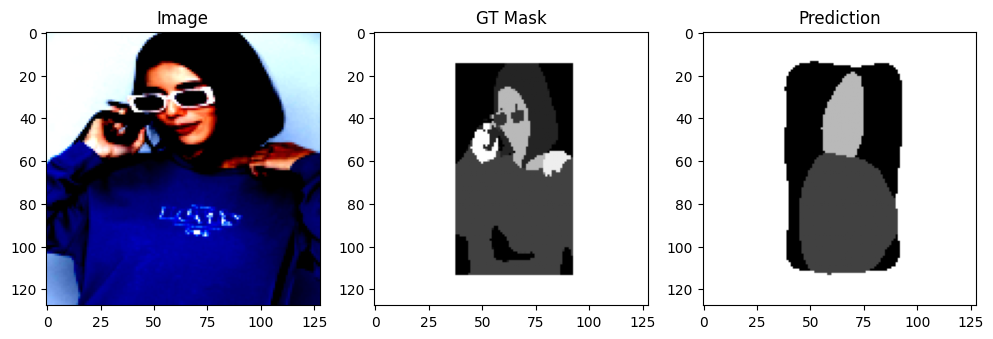

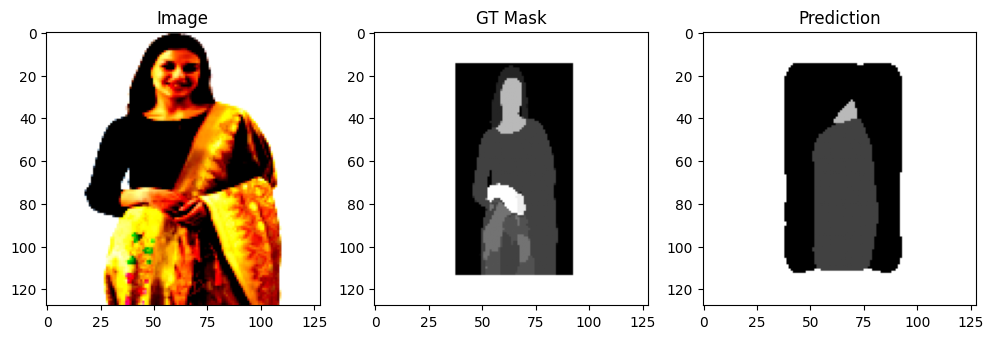

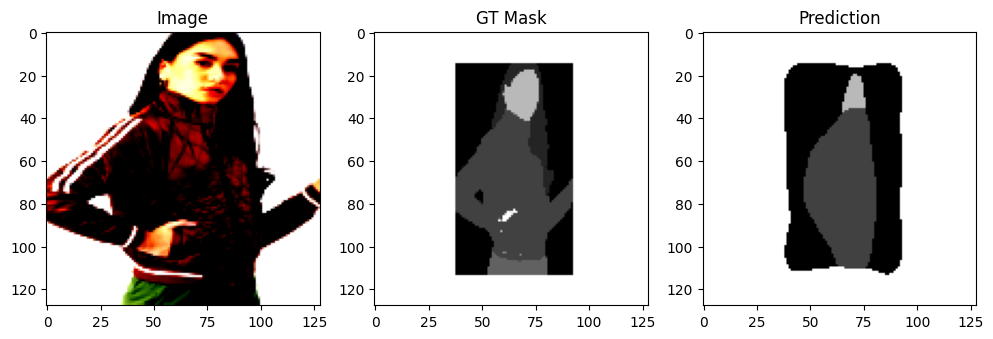

In [ ]:
model.eval()
for i in range(3):
    batch = val_dataset[i]
    pixel_values = batch["pixel_values"].unsqueeze(0).to(device)
    labels = batch["labels"].cpu().numpy()
    with torch.no_grad():
        logits = model(pixel_values=pixel_values).logits
        logits = F.interpolate(logits, size=labels.shape, mode='bilinear', align_corners=False)
        pred_mask = torch.argmax(logits, dim=1).cpu().squeeze().numpy()
    img = pixel_values.cpu().squeeze().permute(1,2,0).numpy()
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Image")
    plt.subplot(1,3,2); plt.imshow(labels, cmap="gray"); plt.title("GT Mask")
    plt.subplot(1,3,3); plt.imshow(pred_mask, cmap="gray"); plt.title("Prediction")
    plt.show()
